# What is the most optimal skill to learn for Data Analysts?

### Methodology

1. Group skills to determine median salary and likelihood of being in posting
2. Visualise median salary vs percent skill demand
3. (Optional) Determine if certain technologies are more prevalent 

In [1]:
import os

os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["HF_DATASETS_OFFLINE"] = "1"

In [2]:
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

Using the latest cached version of the dataset since lukebarousse/data_jobs couldn't be found on the Hugging Face Hub (offline mode is enabled).
Found the latest cached dataset configuration 'default' at C:\Users\ecritchley\.cache\huggingface\datasets\lukebarousse___data_jobs\default\0.0.0\ed776e5a0a8c40ea9d5efbd800772ae52e140f3e (last modified on Wed Jun 17 13:55:44 2026).


In [3]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

In [4]:
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

df_DA_US_exploded = df_DA_US.explode('job_skills')

df_DA_US_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [13]:
df_DA_skills = df_DA_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

DA_job_count = len(df_DA_US)

df_DA_skills['skill_percent'] = df_DA_skills['skill_count'] / DA_job_count * 100

skill_percent = 5

df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percent'] > skill_percent]

df_DA_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


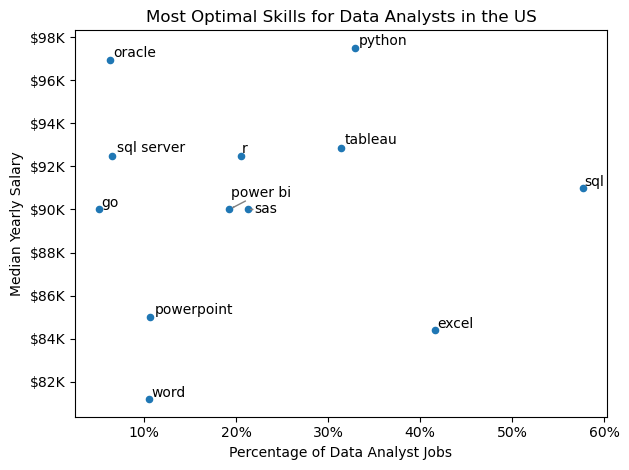

In [19]:
from adjustText import adjust_text

df_DA_skills_high_demand.plot(kind='scatter', x='skill_percent', y='median_salary')

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], txt))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

plt.xlabel('Percentage of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the US')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.tight_layout()
plt.show()

In [20]:
df['job_type_skills'].head(10)

0                                                  NaN
1    {'analyst_tools': ['power bi', 'tableau'], 'pr...
2    {'analyst_tools': ['dax'], 'cloud': ['azure'],...
3    {'cloud': ['aws'], 'libraries': ['tensorflow',...
4    {'cloud': ['oracle', 'aws'], 'other': ['ansibl...
5    {'cloud': ['gcp'], 'programming': ['python', '...
6    {'cloud': ['gcp', 'bigquery'], 'databases': ['...
7    {'cloud': ['gcp', 'azure', 'aws', 'bigquery', ...
8    {'analyst_tools': ['excel', 'powerpoint', 'pow...
9    {'analyst_tools': ['excel'], 'cloud': ['azure'...
Name: job_type_skills, dtype: str

In [21]:
df_technology = df['job_type_skills'].copy()

# remove duplicates

df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row) # convert string to dictionary
    for key, value in row_dict.items():
            if key in technology_dict: # if key already exists in technology_dict, add value to existing value
                  technology_dict[key] += value
            else:                       # if key does not exist in technology_dict, add key & value
                  technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
      technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['spss',
  'microstrategy',
  'alteryx',
  'word',
  'qlik',
  'sharepoint',
  'ssrs',
  'msaccess',
  'splunk',
  'dax',
  'ssis',
  'power bi',
  'cognos',
  'sap',
  'sheets',
  'esquisse',
  'datarobot',
  'outlook',
  'powerbi',
  'sas',
  'nuix',
  'powerpoint',
  'spreadsheet',
  'ms access',
  'looker',
  'visio',
  'tableau',
  'excel'],
 'programming': ['erlang',
  'python',
  'shell',
  'apl',
  'lua',
  'visualbasic',
  'sass',
  'visual basic',
  'solidity',
  'kotlin',
  'mongodb',
  'dart',
  'html',
  'golang',
  'typescript',
  'bash',
  't-sql',
  'javascript',
  'crystal',
  'scala',
  'vb.net',
  'lisp',
  'sas',
  'objective-c',
  'delphi',
  'go',
  'matlab',
  'php',
  'ruby',
  'sql',
  'ocaml',
  'f#',
  'c++',
  'fortran',
  'powershell',
  'julia',
  'c#',
  'nosql',
  'haskell',
  'assembly',
  'r',
  'perl',
  'swift',
  'elixir',
  'mongo',
  'cobol',
  'pascal',
  'vba',
  'java',
  'c',
  'clojure',
  'css',
  'no-sql',
  'rust',
  'gro

In [22]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,spss
0,analyst_tools,microstrategy
0,analyst_tools,alteryx
0,analyst_tools,word
0,analyst_tools,qlik
...,...,...
9,sync,zoom
9,sync,google chat
9,sync,symphony
9,sync,ringcentral


In [24]:
df_plot = df_DA_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='skills')

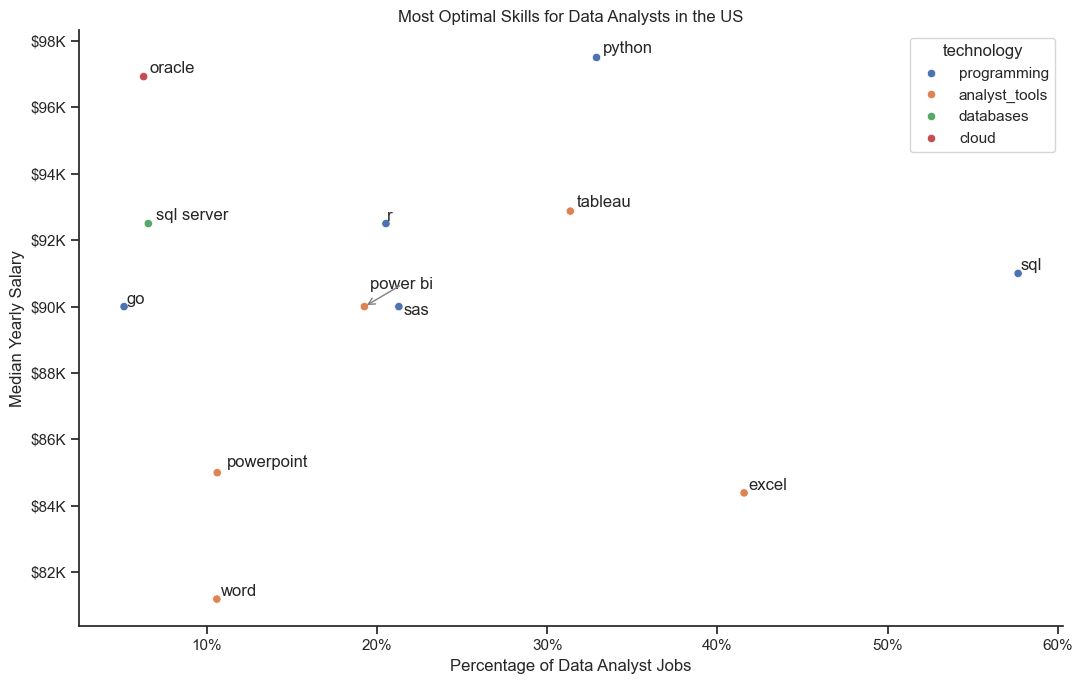

In [38]:
from adjustText import adjust_text

sns.set_theme(style='ticks')
plt.figure(figsize=(11,7))

# df_plot.plot(kind='scatter', x='skill_percent', y='median_salary')
sns.scatterplot(
    data=df_plot,
    x='skill_percent',
    y='median_salary',
    hue='technology'
)

sns.despine()


# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], txt))

# Adjust text to avoid overlap
adjust_text(
    texts,
    only_move={'points': 'y', 'texts': 'xy'},
    expand_text=(2, 2),
    expand_points=(2, 2),
    force_text=(1, 1),
    force_points=(1, 1),
    arrowprops=dict(arrowstyle='->', color='gray')
)

plt.xlabel('Percentage of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the US')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.tight_layout()
plt.show()

In [33]:
import adjustText
print(adjustText.__version__)

1.4.0
